In [ ]:
This project analyzes the global spread of COVID-19 and its impact across multiple countries using publicly available data. 

#It includes interactive and static visualizations to explore:
Total & new COVID-19 cases
Vaccination progress
Deaths per country
Trends over time normalized by population
Relationship between vaccinations and case reduction

#Goal:
-To demonstrate the ability to:
-Handle real-world messy data
-Visualize key health and policy indicators clearly
-Derive actionable insights that could aid public health or decision-making

#Tools Used:
~Python
 -Pandas
 -Matplotlib
 -Seaborn
 -Plotly
~Jupyter Notebook
~Public dataset from Our World in Data

In [5]:
#importing the dataset
import pandas as pd
df = pd.read_csv('https://covid.ourworldindata.org/data/owid-covid-data.csv')
df.head() 

URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [4]:
#cleaning and filtering dataset
df = df[['location', 'date', 'new_cases', 'total_cases', 'new_deaths', 'population']]
df['date'] = pd.to_datetime(df['date'])
countries = ['United States', 'India', 'Brazil']
df = df[df['location'].isin(countries)] 

NameError: name 'df' is not defined

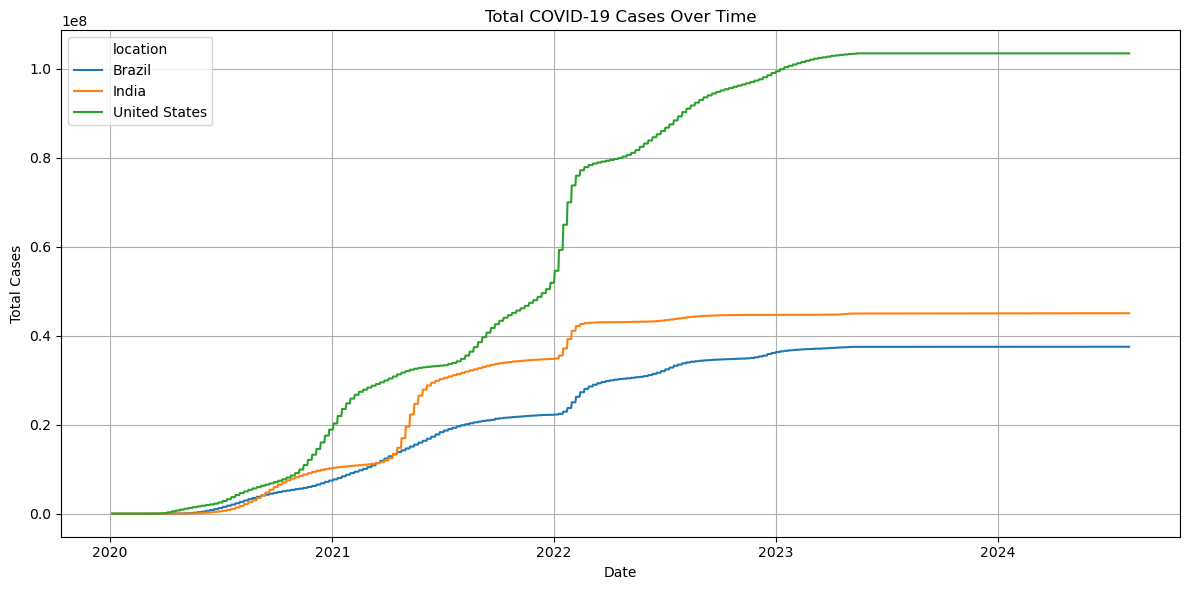

In [7]:
#Visualizing the data
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='date', y='total_cases', hue='location')
plt.title('Total COVID-19 Cases Over Time')
plt.xlabel('Date'); plt.ylabel('Total Cases')
plt.grid(True)
plt.tight_layout()
plt.show() 

In [1]:
import plotly.express as px

map_df = latest[latest['location'].isin(countries)]
fig = px.choropleth(map_df, 
                    locations="location",
                    locationmode="country names",
                    color="total_cases",
                    hover_name="location",
                    title="Total COVID-19 Cases (Latest Date)")
fig.show()  

NameError: name 'latest' is not defined

In [13]:
#including vacciantion columns 
df = pd.read_csv('https://covid.ourworldindata.org/data/owid-covid-data.csv')
df = df[['location', 'date', 'total_cases', 'total_deaths',
         'people_fully_vaccinated_per_hundred', 'population']]
df['date'] = pd.to_datetime(df['date'])
df = df[df['location'].isin(['United States', 'India', 'Brazil'])] 

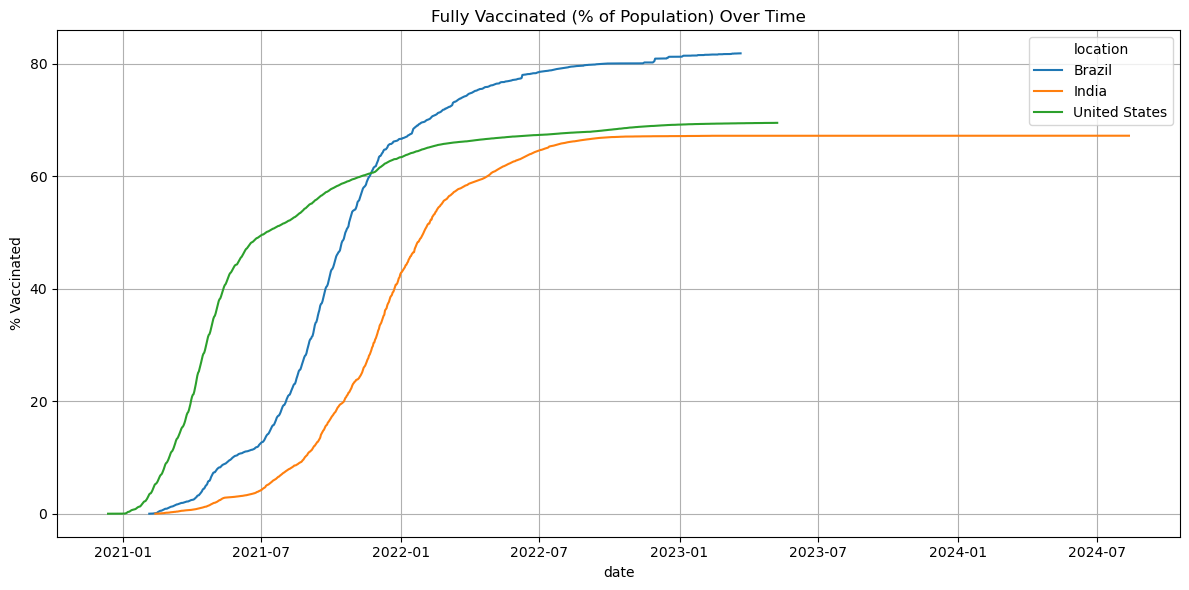

In [16]:
#plotting vaccination trending over time 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='date', y='people_fully_vaccinated_per_hundred', hue='location')
plt.title('Fully Vaccinated (% of Population) Over Time')
plt.ylabel('% Vaccinated')
plt.grid(True)
plt.tight_layout()
plt.show() 

In [20]:
#creating a per million column 
df['cases_per_million'] = (df['total_cases'] / df['population']) * 1_000_000 

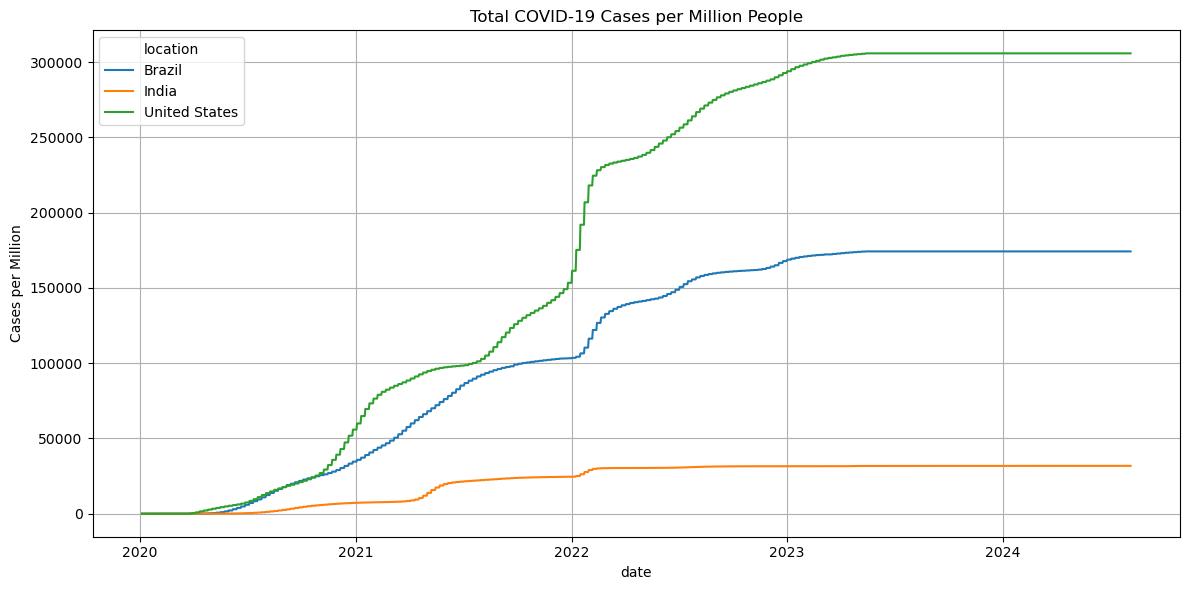

In [22]:
#plotting normalised cases by population 
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='date', y='cases_per_million', hue='location')
plt.title('Total COVID-19 Cases per Million People')
plt.ylabel('Cases per Million')
plt.grid(True)
plt.tight_layout()
plt.show() 

In [24]:
#animated global spread 
#prepping data for animation 

import plotly.express as px

map_df = df[['location', 'date', 'total_cases']]
map_df = map_df[map_df['date'] >= '2021-01-01'] 

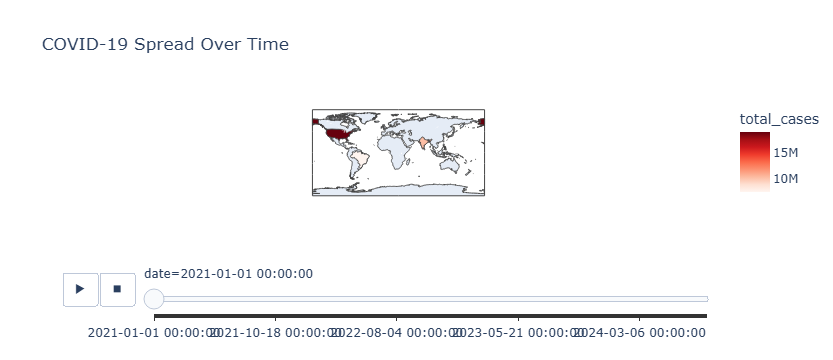

In [26]:
#code for building animated map
fig = px.choropleth(map_df,
                    locations="location",
                    locationmode="country names",
                    color="total_cases",
                    hover_name="location",
                    animation_frame="date",
                    title="COVID-19 Spread Over Time",
                    color_continuous_scale='Reds')
fig.show()

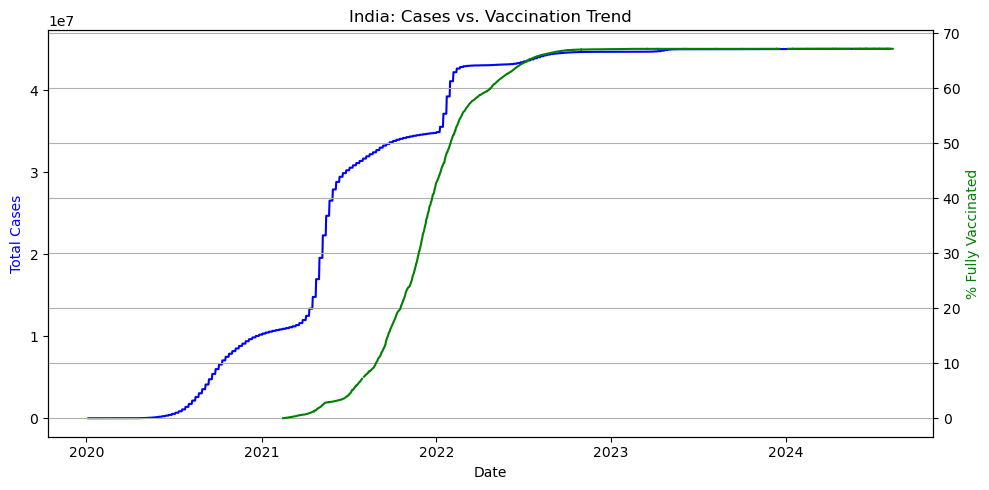

In [30]:
#Considering an example to compare metrics such as dual axis chart
 #CASESvsVACCINATION 

india = df[df['location'] == 'India']
fig, ax1 = plt.subplots(figsize=(10,5))

ax2 = ax1.twinx()
ax1.plot(india['date'], india['total_cases'], color='blue', label='Total Cases')
ax2.plot(india['date'], india['people_fully_vaccinated_per_hundred'], color='green', label='% Vaccinated')

ax1.set_xlabel('Date')
ax1.set_ylabel('Total Cases', color='blue')
ax2.set_ylabel('% Fully Vaccinated', color='green')
plt.title('India: Cases vs. Vaccination Trend')
plt.grid(True)
plt.tight_layout()
plt.show() 